## Visualization of best features - indicators of condition of patient - As per Summary Statistics

##### Hand crafted data 

### Let's visualize feature importance for quality assessment techniques within each stroke patient

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mock data generation (simulating the 'overall' table)
np.random.seed(42)
overall = pd.read_csv('overall_patients/overall_measures.csv')

In [20]:
# Group by patient and condition, then compute mean per patient per side
summary = overall.groupby(['participant_id', 'condition'])['Mean_hand_velocity'].mean().unstack()


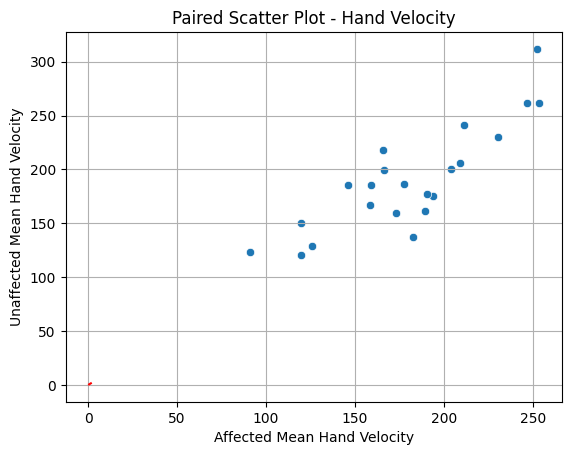

In [21]:
sns.scatterplot(x=summary['affected'], y=summary['unaffected'])
plt.plot([0, 2], [0, 2], linestyle='--', color='red')
plt.xlabel('Affected Mean Hand Velocity')
plt.ylabel('Unaffected Mean Hand Velocity')
plt.title('Paired Scatter Plot - Hand Velocity')
plt.grid(True)
plt.show()


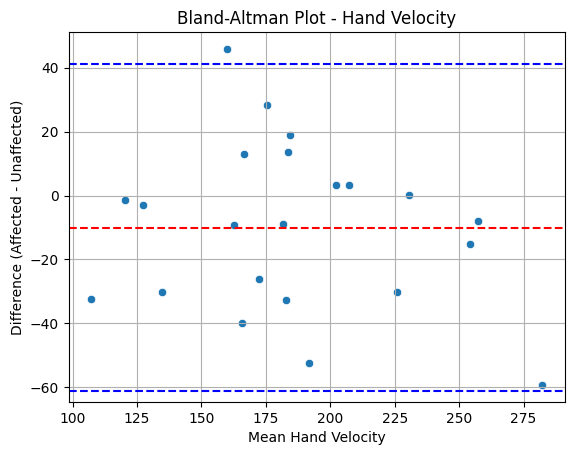

In [22]:
mean_diff = summary.mean(axis=1)
diff = summary['affected'] - summary['unaffected']

sns.scatterplot(x=mean_diff, y=diff)
plt.axhline(diff.mean(), color='red', linestyle='--')
plt.axhline(diff.mean() + 1.96 * diff.std(), color='blue', linestyle='--')
plt.axhline(diff.mean() - 1.96 * diff.std(), color='blue', linestyle='--')
plt.xlabel('Mean Hand Velocity')
plt.ylabel('Difference (Affected - Unaffected)')
plt.title('Bland-Altman Plot - Hand Velocity')
plt.grid(True)
plt.show()


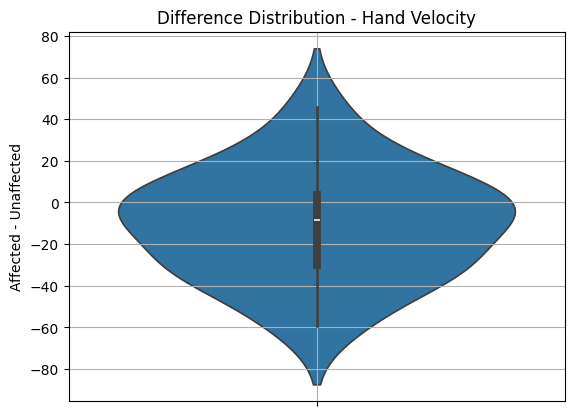

In [23]:
diff = summary['affected'] - summary['unaffected']
sns.violinplot(y=diff, inner='box')
plt.title('Difference Distribution - Hand Velocity')
plt.ylabel('Affected - Unaffected')
plt.grid(True)
plt.show()


## Key takeaways from the previous violin plot :
- Most patients have a lower hand velocity on the affected side 
- There is variability, with some outliers in both cases
- Good support for further statistical comparison or modelling based on this feature

# ❓ Which kinematic features are most informative for identifying the condition?



## Feature importance via a classifier 

C:\Users\shrinidhi.velan\AppData\Local\Temp\ipykernel_17608\1157038353.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


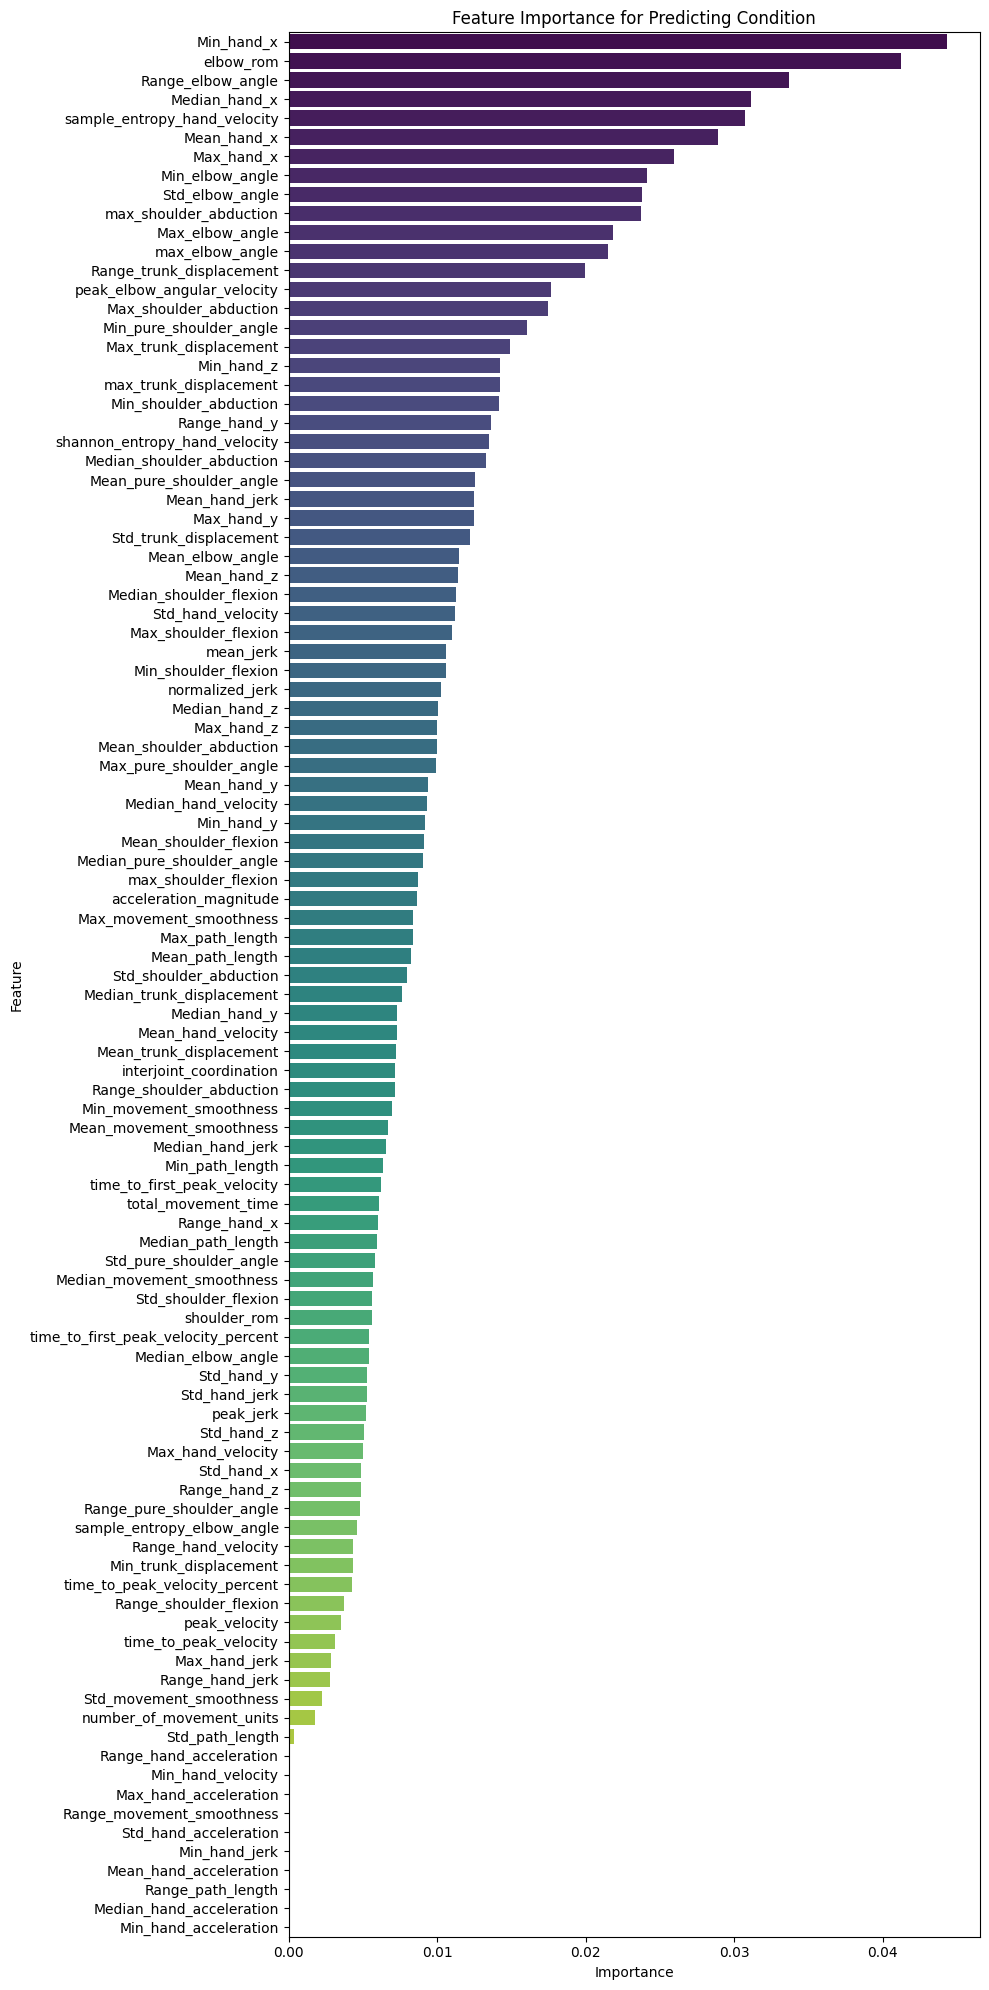

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Drop any non-feature columns (like IDs or string labels)
# You can list them explicitly or infer which are numeric
X = overall.drop(columns=['condition', 'trial_number'])  # Drop condition column
X = X.select_dtypes(include='number')    # Keep only numeric columns

# Encode condition to binary (0 = unaffected, 1 = affected)
y = LabelEncoder().fit_transform(overall['condition'])

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get and plot importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 20))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance for Predicting Condition')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


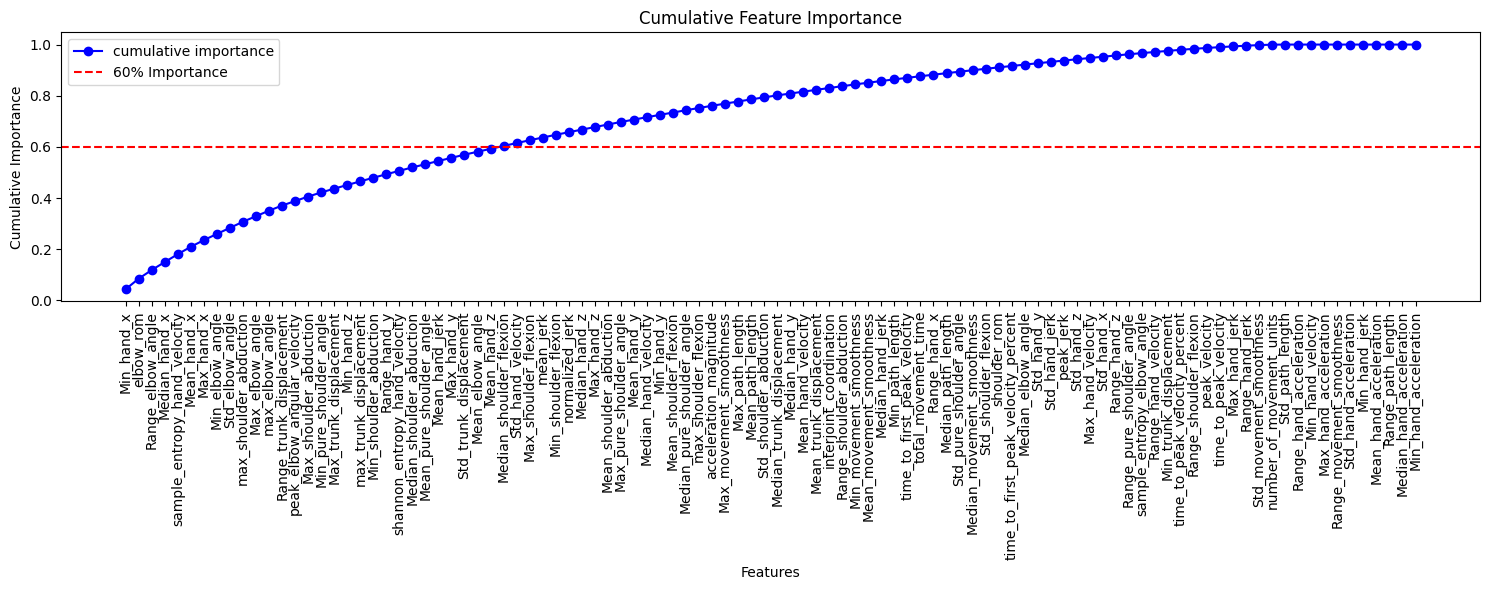

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Sort importances in descending order
sorted_importances = importances.sort_values(ascending=False)

# Cumulative sum of importances
cumulative_importance = np.cumsum(sorted_importances.values)

# Plot cumulative importance
plt.figure(figsize=(15, 6))
plt.plot(sorted_importances.index, cumulative_importance, marker='o', color='blue', label = 'cumulative importance')
plt.title('Cumulative Feature Importance')
plt.xlabel('Features')
plt.ylabel('Cumulative Importance')
plt.xticks(rotation=90)
plt.axhline(y=0.60, color='red', linestyle='--', label='60% Importance')

plt.tight_layout()
plt.legend()
plt.show()


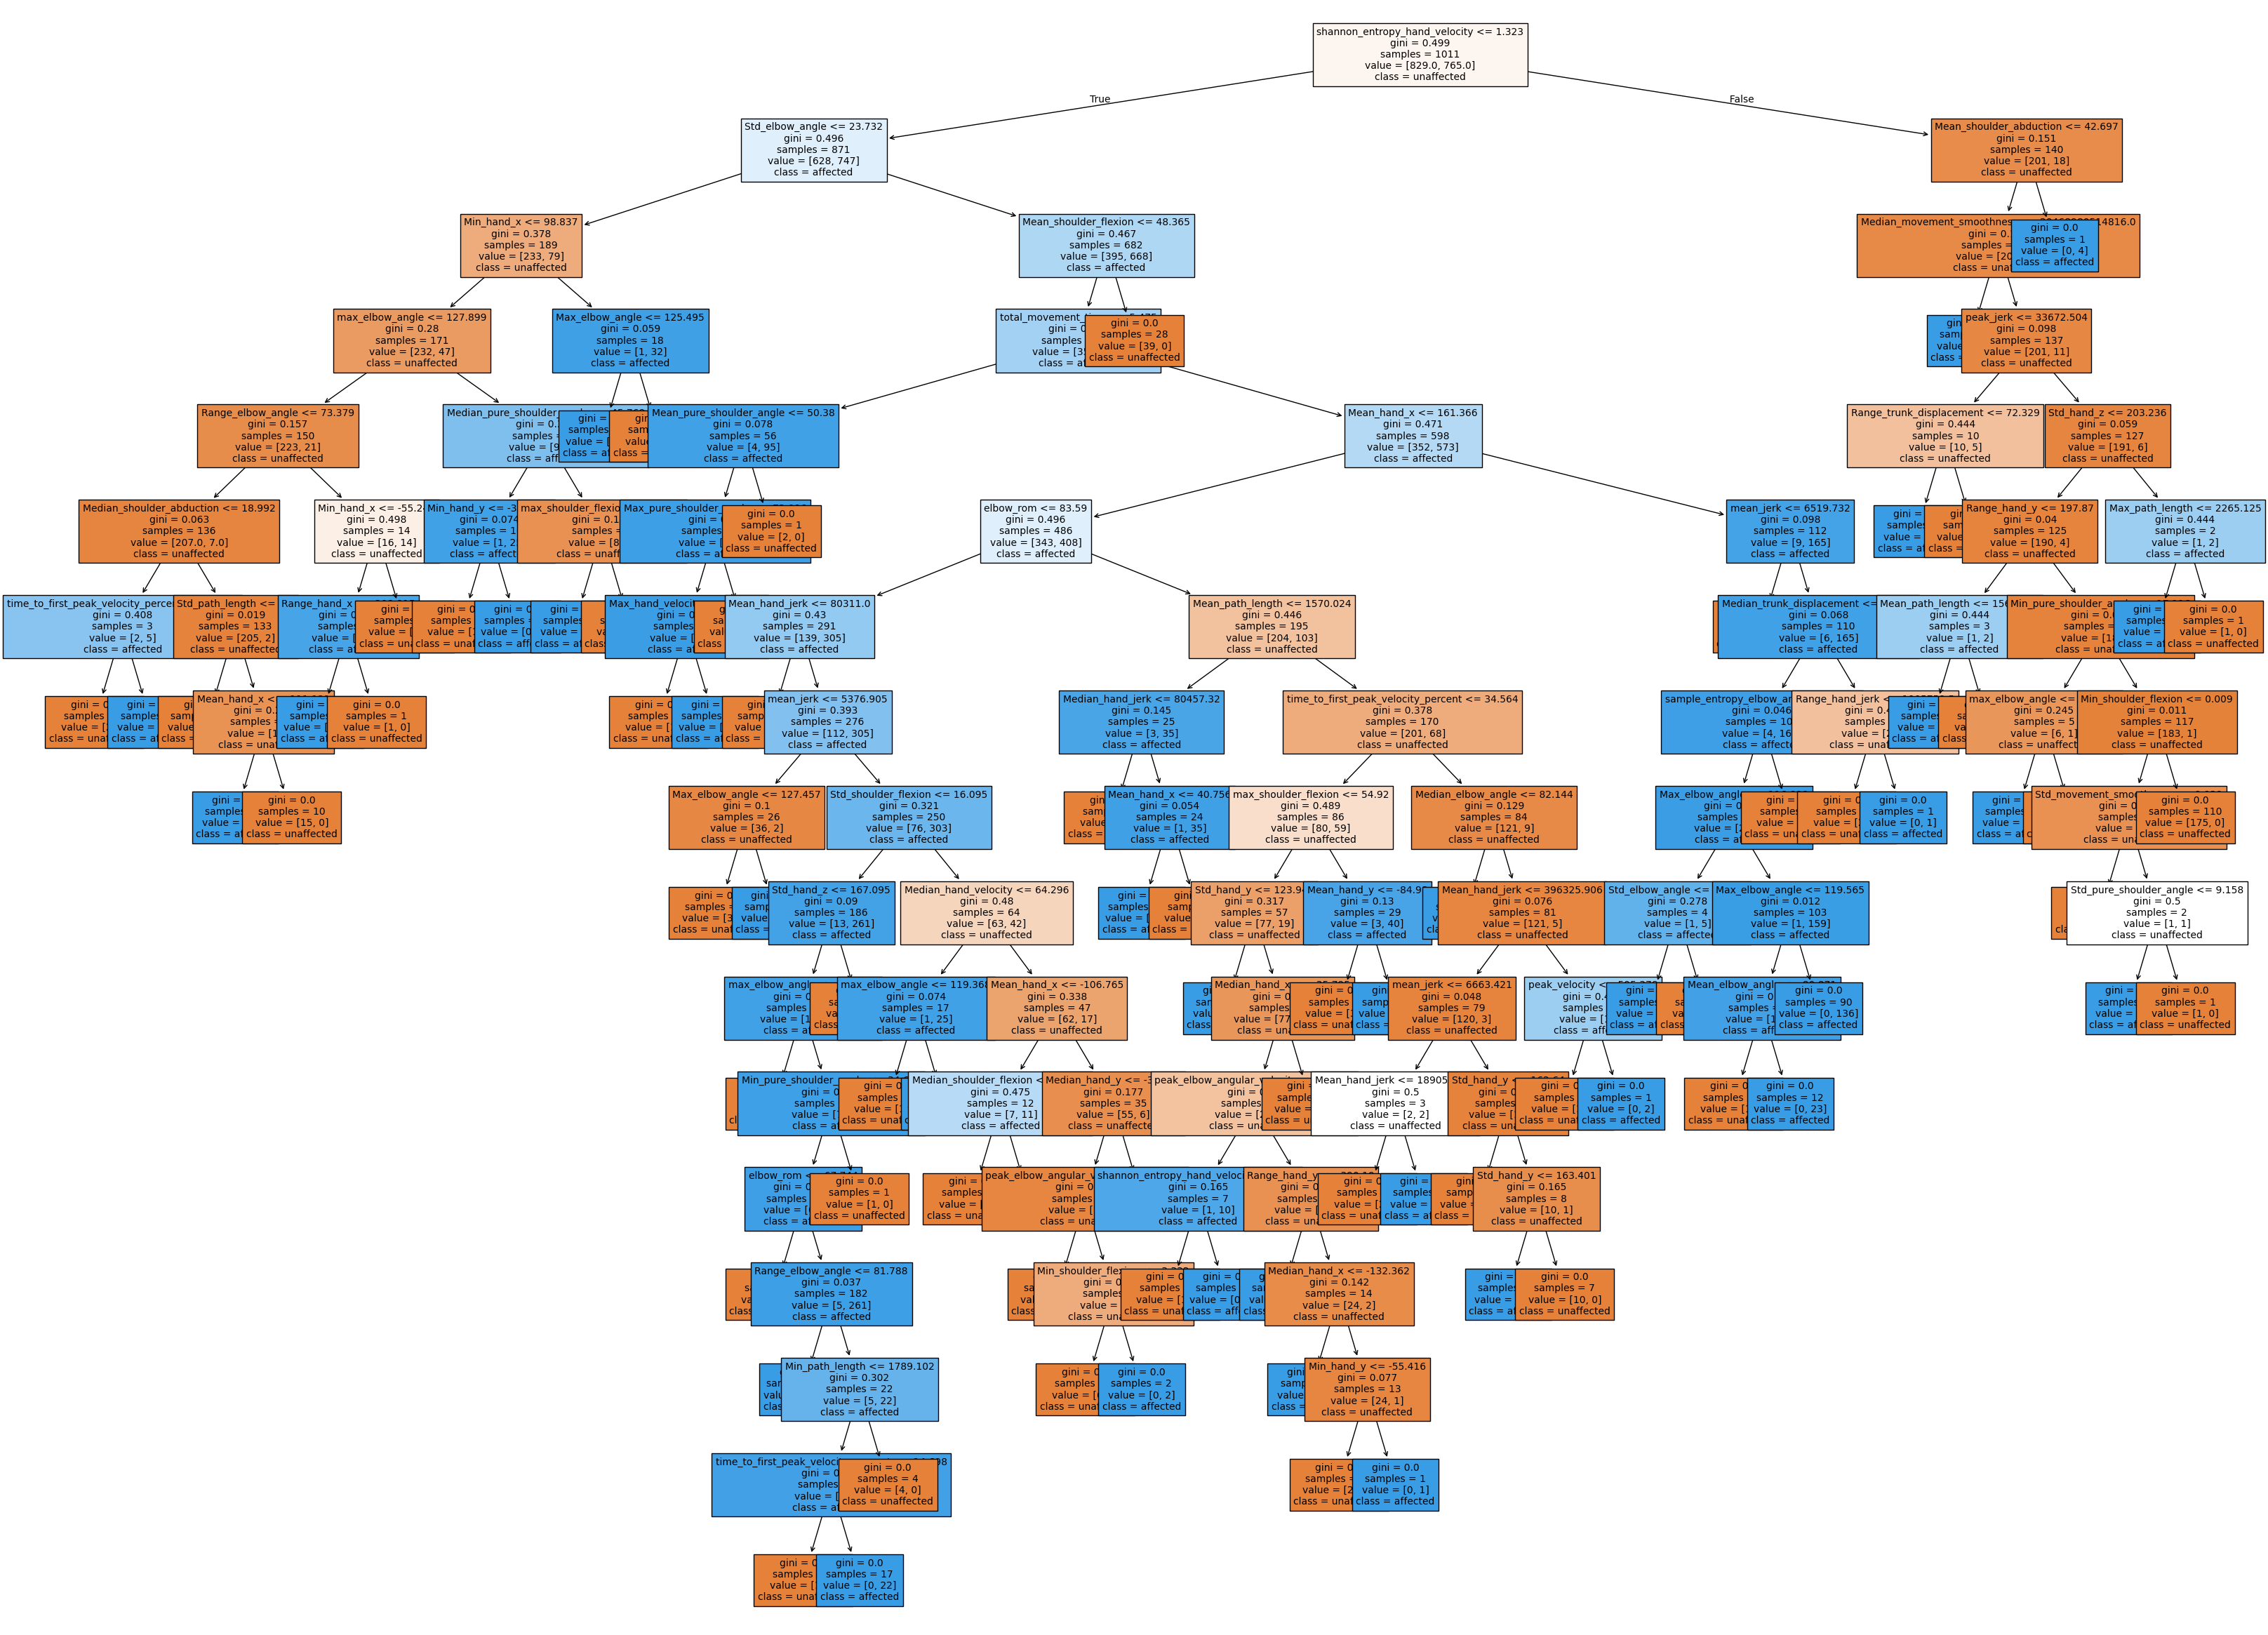

In [53]:
from sklearn.tree import plot_tree

# Plot the first decision tree from the forest
plt.figure(figsize=(40, 30))
plot_tree(model.estimators_[0], feature_names=X.columns, filled=True, class_names=['unaffected', 'affected'], fontsize=10)
plt.show()


### AUC/ROC for Random Forests

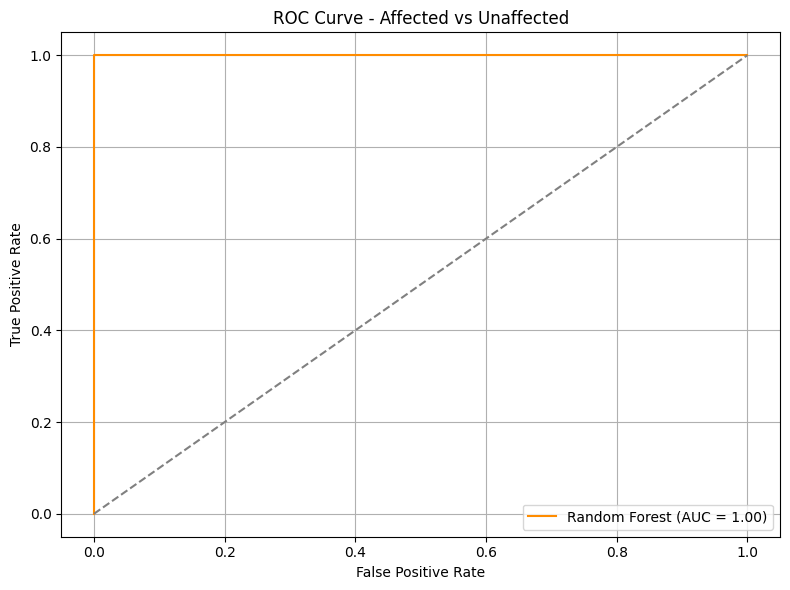

In [67]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Step 1: Encode target
y = LabelEncoder().fit_transform(overall['condition'])

# Step 2: Keep only numeric features
X = overall.drop(columns=['condition', 'trial_number'])
X = X.select_dtypes(include='number')

# Step 3: Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Step 4: Fit model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 5: Predict probabilities
y_proba = model.predict_proba(X_test)[:, 1]  # probability for class 'affected' (1)

# Step 6: Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Step 7: Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Affected vs Unaffected')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


## Univariate Statistical Tests


C:\Users\shrinidhi.velan\AppData\Local\Temp\ipykernel_17608\1992384161.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pvals.iloc[:top_n].values, y=pvals.iloc[:top_n].index, palette='coolwarm_r')


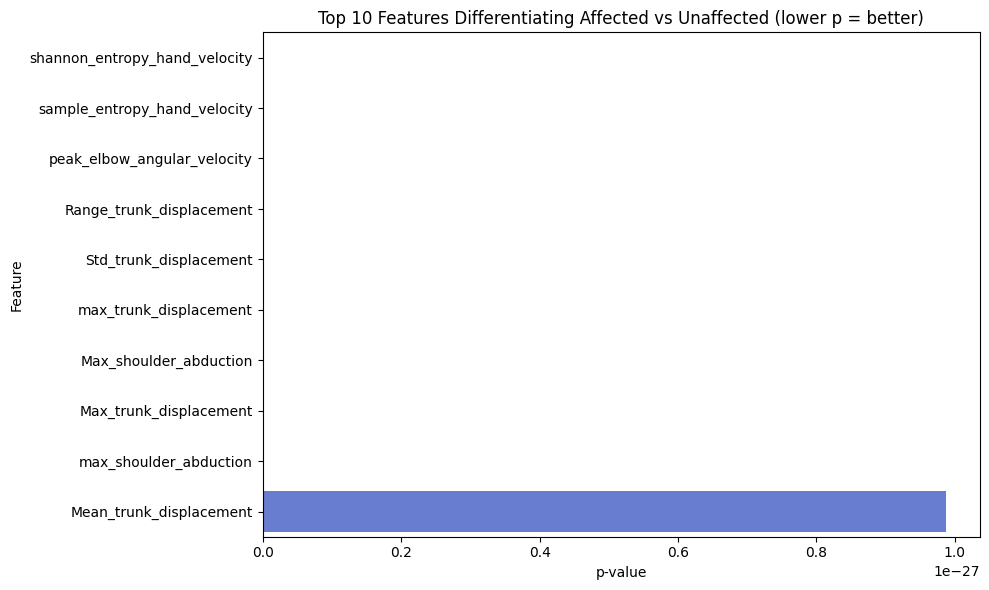

In [43]:
from scipy.stats import ttest_ind
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-feature columns
non_feature_cols = ['participant_id', 'trial_number', 'side', 'condition']
X = overall.drop(columns=non_feature_cols)

# Keep only numeric columns just to be safe
X = X.select_dtypes(include='number')

# Get condition labels
condition = overall['condition']

# Separate affected and unaffected groups
affected = X[condition == 'affected']
unaffected = X[condition == 'unaffected']

# Run independent t-tests and store p-values
p_values = {}
for col in X.columns:
    t_stat, p_val = ttest_ind(affected[col], unaffected[col], equal_var=False)
    p_values[col] = p_val

# Sort by significance
pvals = pd.Series(p_values).sort_values()

# Plot top N features
top_n = 10
plt.figure(figsize=(10, 6))
sns.barplot(x=pvals.iloc[:top_n].values, y=pvals.iloc[:top_n].index, palette='coolwarm_r')
plt.title(f'Top {top_n} Features Differentiating Affected vs Unaffected (lower p = better)')
plt.xlabel('p-value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
